# Fly-analysis plot recreation from pooled pipeline outputs

This notebook recreates the fly-only analyses from `bermanlabemory/slowmode` using matrices produced by `all_pair_distance_pipeline.ipynb`. It never executes or imports the producing notebook. Run it only after the projection and state files are complete.

Coverage: main Figures 4 and 5 and fly analyses from Supplements S7-S11. The fixed-timescale control, behavior-map density, held-out CV matrix, and per-individual refit cosines are optional imports because they are separate analyses rather than outputs of the multi-timescale run.

In [3]:
from pathlib import Path
import importlib
import pickle
import sys
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path('/Users/meganbishop/slowmodeevo')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import fly_plot_recreation as fpr
fpr = importlib.reload(fpr)

# Point this at any completed pooled run. The default is the current tuning run.
RUN_ROOT = REPO_ROOT / 'outputs' / 'tuning' / 'Peromyscus_californicus'
FS_HZ = 120.0  # Set to the TUNING_FS printed by the producing notebook.
TAU_SECONDS = 5
N_BASINS = 6
SAVE_FIGURES = False
FIGURE_DIR = RUN_ROOT / 'fly_style_plot_recreations'

# Optional matrices. Leave as None when unavailable.
FIXED_TIMESCALE_NPZ = None       # NPZ containing `phi`, or a compatible dict
BEHAVIOR_DENSITY_NPZ = None      # keys: cond, x_edges, y_edges
CAO_E1_NPY = None
ENTROPY_GAP_NPZ = None           # keys: N, gap
CV_PI_NPY = None
ARM_COSINES_NPY = None
MOSEQ_TIMESERIES_CSV = Path('/Users/meganbishop/moseq_dataverse/multispecies_moseq_timeseries.csv')
MOSEQ_LABELS_CSV = 'https://docs.google.com/spreadsheet/ccc?key=1sElHrwyuvw0KMIYFKhOkT4jasWYJnBBlEEHffqt8x-k&output=csv&gid=1217005544'
RUN_MOSEQ_ARM_JOIN = True
MOSEQ_MIN_MATCHED_FRAMES = 0
MOSEQ_MAX_CLUSTERS_TO_PLOT = 50
MOSEQ_TOP_CLUSTERS_PER_ARM = None  # None plots all non-noise syllables per nested arm.
MOSEQ_DENSITY_TOP_N = None  # None plots all non-noise syllables per nested arm.
MOSEQ_MIN_DOMINANCE_FRACTION = 0.0
MOSEQ_EXCLUDED_CATEGORIES = ('noise',)

# Transfer-operator visualization.
RUN_TRANSFER_OPERATOR_PLOTS = True
INDIVIDUALS_PER_PAGE = 6
TRANSFER_VISITED_STATES_ONLY = True

# Optional occupancy filter. Figure 4 refits T/eigenvectors/GPCCA after dropping.
# Transfer-operator heatmaps display the same retained cluster subset.
DROP_LOW_TIME_CLUSTERS = False
DROP_LOWEST_CLUSTER_FRACTION = 0.90
MIN_CLUSTER_TIME_SECONDS = None  # Set a number to override the fraction cutoff.


# Recursive GPCCA split layer. This tests each current chi arm for a nested slow mode.
RUN_RECURSIVE_ARM_SPLITTING = False
MIN_PARENT_CLUSTERS_TO_SPLIT = 20
MIN_CHILD_BALANCE = 0.1
MIN_PARENT_OPERATOR_GAP_RATIO = 1.3
MIN_CHILD_GLOBAL_PI = 0.05
MAX_RECURSIVE_SPLIT_DEPTH = 4  # safety cap; stopping is governed by thresholds above.
RECURSIVE_NESTED_BASINS = 2
RUN_RECURSIVE_SPLIT_DIAGNOSTICS = True


## Load the completed run

The loader imports `projection_result.pkl` and each individual state array. It reconstructs the pooled transfer operator, stationary distribution, eigenvectors, GPCCA memberships `chi`, hard assignments, and arm geometry in memory.

In [4]:
run = fpr.load_run(RUN_ROOT, fs=FS_HZ, tau_seconds=TAU_SECONDS, n_basins=N_BASINS)
print('individuals:', len(run['states']))
print('clusters:', run['n_clusters'])
print('chi:', run['chi'].shape)
print('transfer operator:', run['T'].shape)
print('lag:', run['lag'], 'frames')

fixed = None if FIXED_TIMESCALE_NPZ is None else dict(np.load(FIXED_TIMESCALE_NPZ))
behavior_density = None if BEHAVIOR_DENSITY_NPZ is None else dict(np.load(BEHAVIOR_DENSITY_NPZ))
cao_e1 = None if CAO_E1_NPY is None else np.load(CAO_E1_NPY)
entropy_gap = None if ENTROPY_GAP_NPZ is None else dict(np.load(ENTROPY_GAP_NPZ))
cv_pi = None if CV_PI_NPY is None else np.load(CV_PI_NPY)
arm_cosines = None if ARM_COSINES_NPY is None else np.load(ARM_COSINES_NPY)

if DROP_LOW_TIME_CLUSTERS:
    PLOT_MIN_CLUSTER_TIME_SECONDS = (
        fpr.cluster_fraction_threshold(run, DROP_LOWEST_CLUSTER_FRACTION)
        if MIN_CLUSTER_TIME_SECONDS is None
        else float(MIN_CLUSTER_TIME_SECONDS)
    )
else:
    PLOT_MIN_CLUSTER_TIME_SECONDS = 0.0
    
print('cluster occupancy cutoff:', PLOT_MIN_CLUSTER_TIME_SECONDS, 'seconds')


/opt/anaconda3/envs/bishop/lib/python3.8/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.6.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


individuals: 15
clusters: 750
chi: (750, 6)
transfer operator: (750, 750)
lag: 600 frames
cluster occupancy cutoff: 0.0 seconds


## Pooled and per-individual transfer operators

All heatmaps use the same cluster order, learned once from the pooled operator, and the same logarithmic color scale. Individual matrices retain the global cluster indices, so empty rows indicate states that individual did not visit.

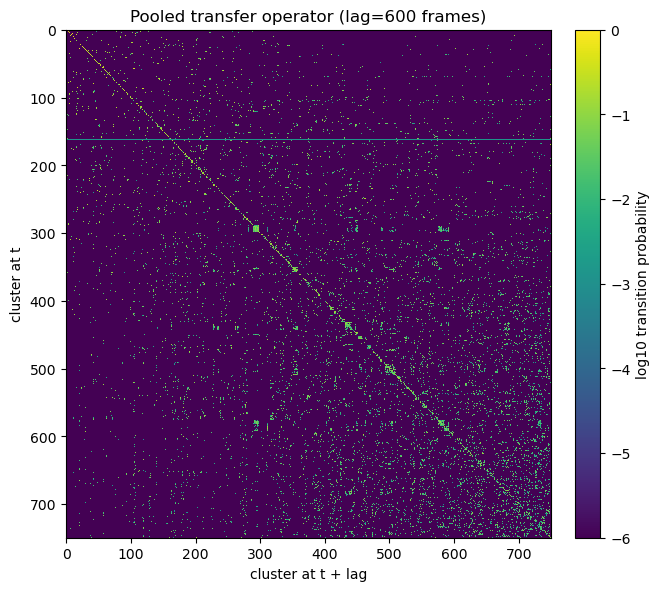

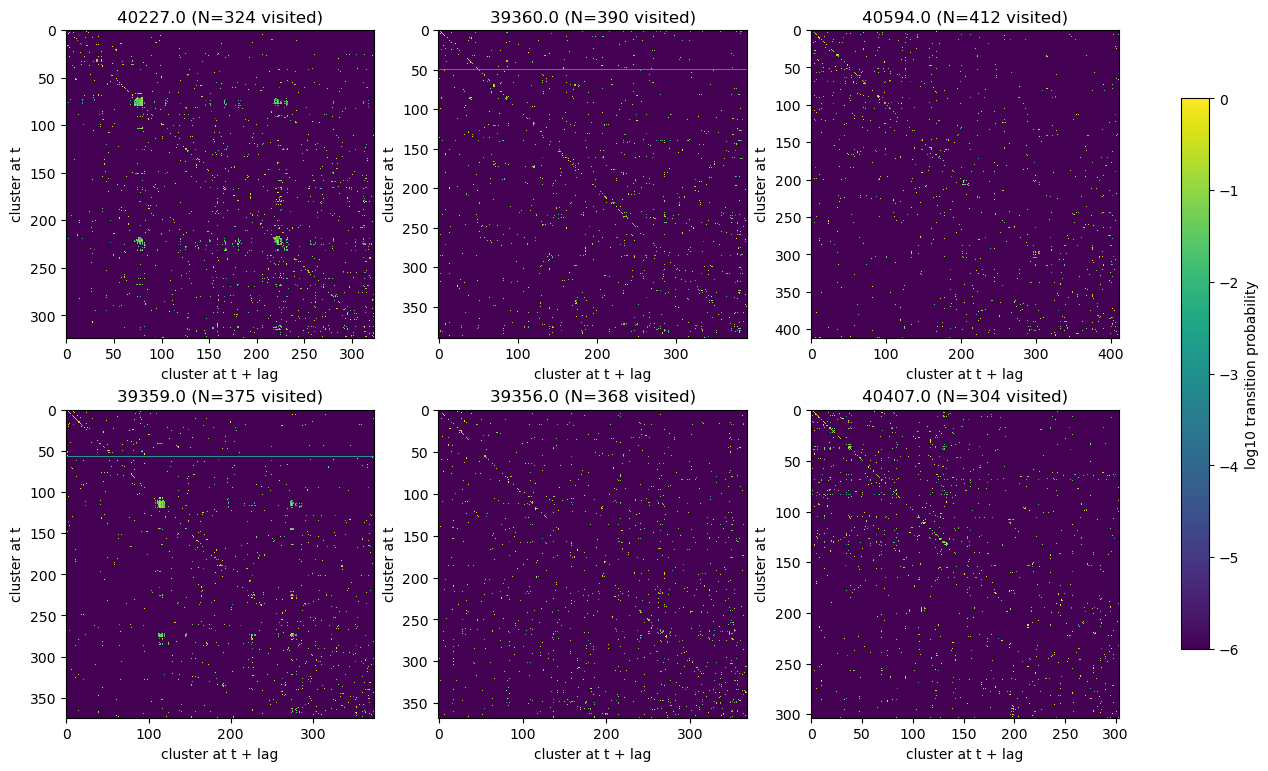

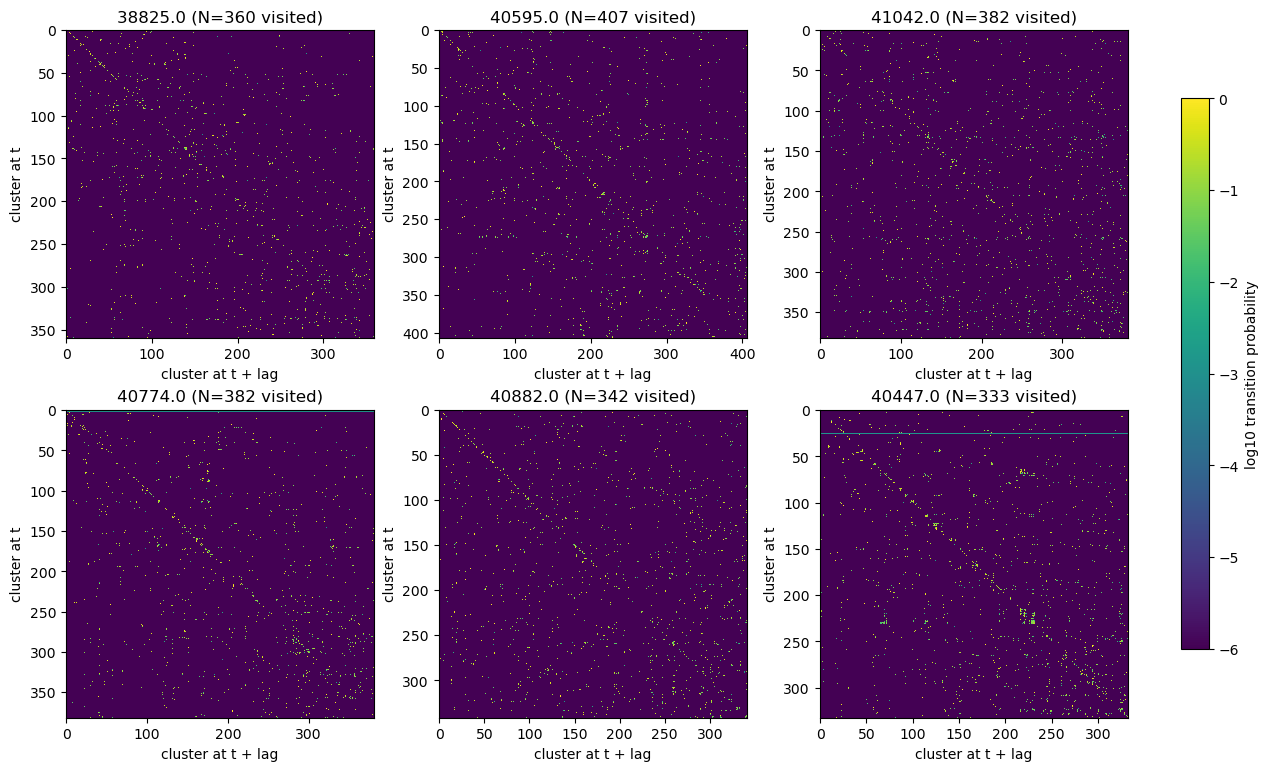

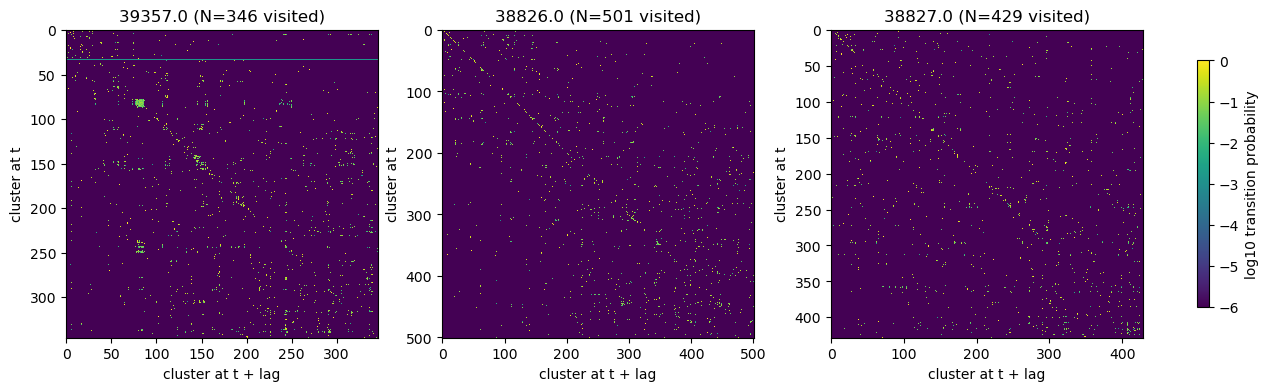

In [5]:
if RUN_TRANSFER_OPERATOR_PLOTS:
    pooled_T_fig, individual_T_figs, transfer_order = fpr.transfer_operator_figures(
        run,
        individuals_per_page=INDIVIDUALS_PER_PAGE,
        visited_only=TRANSFER_VISITED_STATES_ONLY,
        min_cluster_time_seconds=PLOT_MIN_CLUSTER_TIME_SECONDS,
    )
    fpr.maybe_save(pooled_T_fig, FIGURE_DIR, 'transfer_operator_pooled', SAVE_FIGURES)
    plt.show()

    for page, fig in enumerate(individual_T_figs, start=1):
        fpr.maybe_save(fig, FIGURE_DIR, f'transfer_operators_individuals_page_{page:02d}', SAVE_FIGURES)
        plt.show()


## Main Figure 4: slow-mode geometry and collective support

current-run cluster occupancy cutoff: 0.0 seconds
clusters kept: 750 clusters dropped: 0 of 750 total
filter report: /Users/meganbishop/slowmodeevo/outputs/tuning/Peromyscus_californicus/fly_style_plot_recreations/cluster_time_filter_report.csv


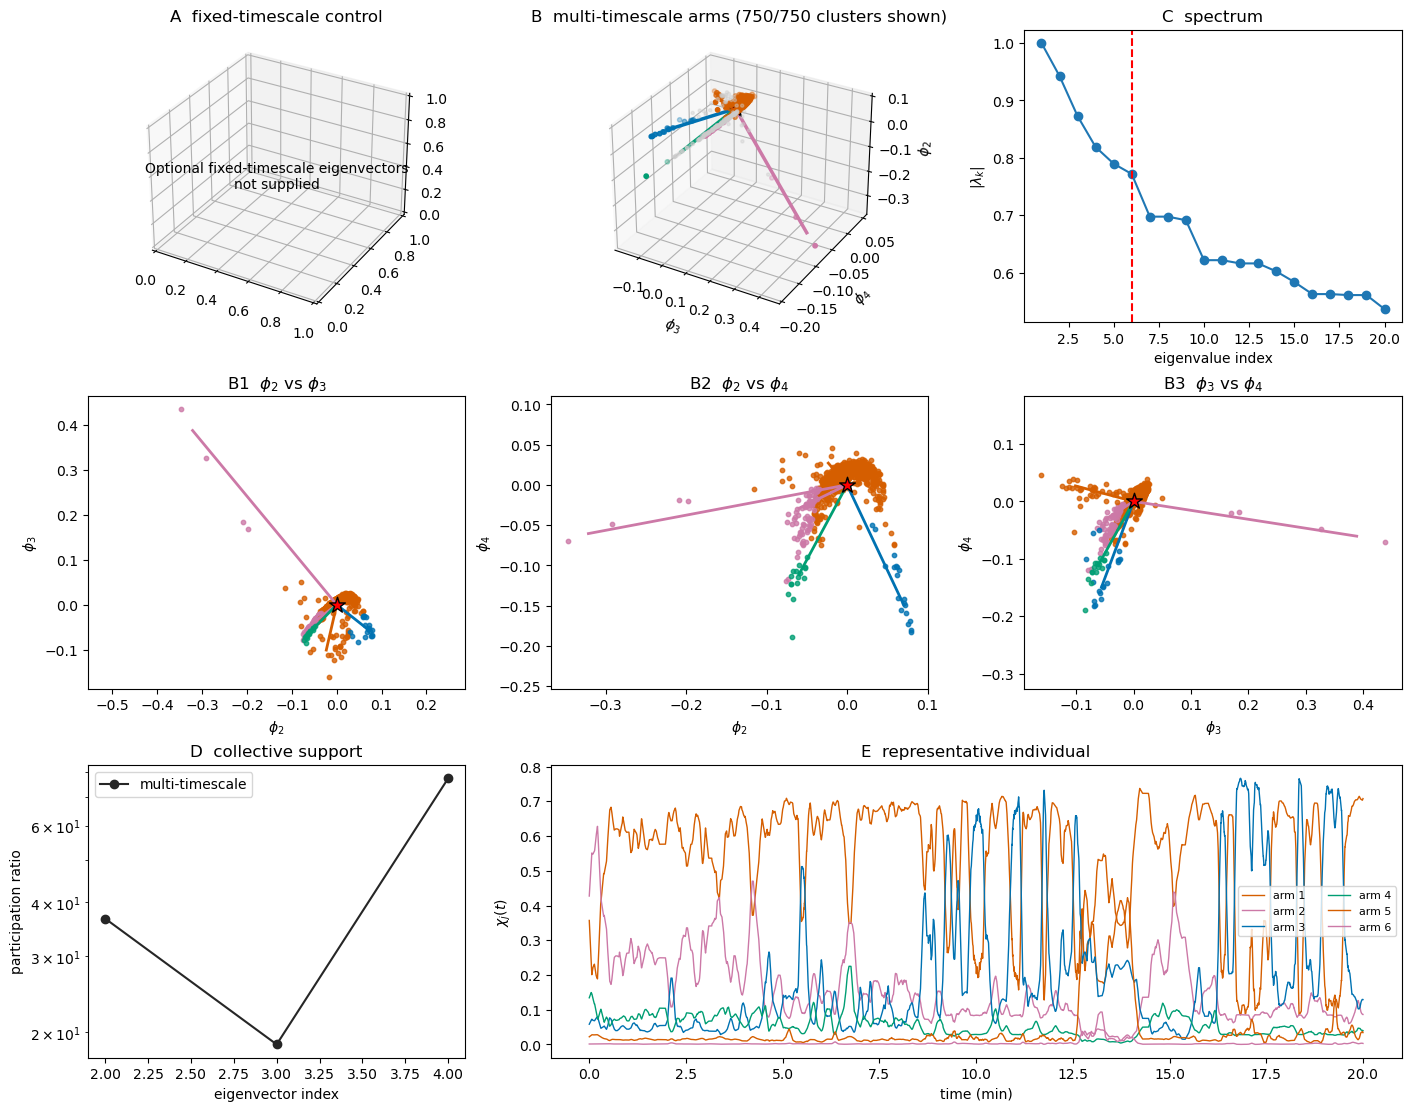

In [6]:
PLOT_MIN_CLUSTER_TIME_SECONDS = (
    fpr.cluster_fraction_threshold(run, DROP_LOWEST_CLUSTER_FRACTION)
    if DROP_LOW_TIME_CLUSTERS and MIN_CLUSTER_TIME_SECONDS is None
    else float(MIN_CLUSTER_TIME_SECONDS or 0.0)
)
print('current-run cluster occupancy cutoff:', PLOT_MIN_CLUSTER_TIME_SECONDS, 'seconds')
filter_report = fpr.export_cluster_time_filter_report(
    run,
    FIGURE_DIR / 'cluster_time_filter_report.csv',
    PLOT_MIN_CLUSTER_TIME_SECONDS,
)
print(
    f"clusters kept: {filter_report['kept_clusters']}",
    f"clusters dropped: {filter_report['dropped_clusters']}",
    f"of {filter_report['total_clusters']} total",
)
print('filter report:', filter_report['path'])
figure4_run = (
    fpr.refit_after_dropping_clusters(run, PLOT_MIN_CLUSTER_TIME_SECONDS)
    if DROP_LOW_TIME_CLUSTERS
    else run
)
if DROP_LOW_TIME_CLUSTERS:
    print('Figure 4 refit clusters:', figure4_run['n_clusters'])
fig4 = fpr.figure_4(
    figure4_run,
    fixed=fixed,
    min_cluster_time_seconds=0.0,
)
fpr.maybe_save(fig4, FIGURE_DIR, 'figure_4', SAVE_FIGURES)
plt.show()

## Recursive GPCCA diagnostics per chi arm

This visualization shows the segment-built within-arm transfer operator and nested GPCCA eigendecomposition that the recursive split rule evaluates inside each current chi arm. It censors frames outside the arm, splits the remaining frames into contiguous bouts, and counts transitions only within those bouts. It is diagnostic only and does not change `figure4_run` or `leaf_run`.


In [7]:
if RUN_RECURSIVE_SPLIT_DIAGNOSTICS:
    split_diagnostics = fpr.recursive_split_diagnostics(
        figure4_run,
        nested_basins=RECURSIVE_NESTED_BASINS,
        min_clusters=MIN_PARENT_CLUSTERS_TO_SPLIT,
    )
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    split_summary_csv = FIGURE_DIR / 'recursive_split_diagnostics_summary.csv'
    split_diagnostics['summary'].to_csv(split_summary_csv, index=False)
    print('split diagnostics summary:', split_summary_csv)
    split_detail_paths = fpr.export_recursive_split_diagnostics(
        split_diagnostics['diagnostics'], FIGURE_DIR
    )
    print('split diagnostic detail tables:', split_detail_paths)
    fig_split_diag = fpr.plot_recursive_split_diagnostics(
        split_diagnostics['diagnostics'],
        child_balance_threshold=MIN_CHILD_BALANCE,
    )
    fpr.maybe_save(
        fig_split_diag, FIGURE_DIR,
        'recursive_split_diagnostics_by_chi_arm', SAVE_FIGURES,
    )
    plt.show()


KeyboardInterrupt: 

## Legacy conditional nested GPCCA inside one global arm

This older diagnostic is kept for comparison only and is off by default. The default nested-arm analysis is the recursive segment-built GPCCA section below, where each split rebuilds a transfer operator from contiguous within-arm bouts.


In [39]:
RUN_CONDITIONAL_NESTED_GPCCA = False


parent basin: 0
parent clusters: 299
parent global pi mass: 0.993125729156724
mean within-parent transition probability: 0.9966386092945683
nested hard cluster counts: [290   9]
nested stationary mass: [0.90613376 0.09386624]
nested cluster table: /Users/meganbishop/slowmodeevo/outputs/single_species_distance_comparison/tuning/egocentered_and_normalized_distances/Peromyscus_californicus/fly_style_plot_recreations/conditional_nested_cluster_assignments.csv


,cluster_id,original_cluster_id,parent_basin,global_pi,global_chi_parent,within_parent_transition_probability,conditional_pi,nested_arm,nested_confidence,nested_chi_0,nested_chi_1
287,288,288,0,0.005551,0.983389,0.999722,0.005608,0,0.961051,0.961051,0.038949
245,246,246,0,0.005435,0.960828,0.996091,0.005479,0,0.920031,0.920031,0.079969
159,159,159,0,0.005443,0.892286,0.990333,0.005453,0,0.783995,0.783995,0.216005
232,232,232,0,0.005392,0.986664,0.997980,0.005452,0,0.976662,0.976662,0.023338
265,266,266,0,0.005157,0.991185,1.000000,0.005211,0,0.977091,0.977091,0.022909
257,258,258,0,0.005058,0.982169,0.998142,0.005113,0,0.964660,0.964660,0.035340
67,67,67,0,0.005002,0.964097,0.995445,0.005053,0,0.931984,0.931984,0.068016
50,50,50,0,0.004915,0.992795,1.000000,0.004968,0,0.982712,0.982712,0.017288
19,19,19,0,0.004946,0.908094,0.985611,0.004950,0,0.840782,0.840782,0.159218
157,157,157,0,0.004701,0.972342,0.999589,0.004747,0,0.934522,0.934522,0.065478


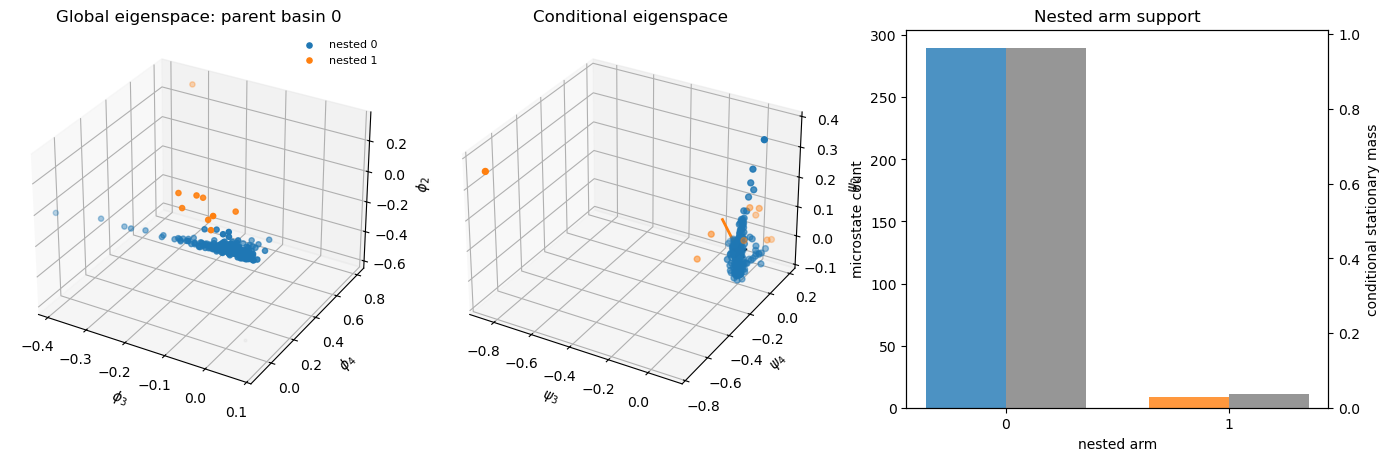

In [40]:
if RUN_CONDITIONAL_NESTED_GPCCA:
    nested = fpr.conditional_nested_gpcca(
        figure4_run,
        parent_basin=CONDITIONAL_PARENT_BASIN,
        n_nested_basins=CONDITIONAL_NESTED_BASINS,
        membership_threshold=CONDITIONAL_MEMBERSHIP_THRESHOLD,
    )
    print('parent basin:', nested['parent_basin'])
    print('parent clusters:', len(nested['parent_clusters']))
    print('parent global pi mass:', nested['parent_global_pi_mass'])
    print('mean within-parent transition probability:', nested['mean_within_parent_transition_probability'])
    print('nested hard cluster counts:', nested['gpcca']['basin_counts'])
    print('nested stationary mass:', nested['gpcca']['pi_basin'])
    nested_table_path = fpr.export_conditional_nested_clusters(
        nested, FIGURE_DIR / 'conditional_nested_cluster_assignments.csv'
    )
    print('nested cluster table:', nested_table_path)
    display(nested['cluster_table'].sort_values(
        ['nested_arm', 'conditional_pi'], ascending=[True, False]
    ).head(30))
    fig_nested = fpr.plot_conditional_nested_gpcca(figure4_run, nested)
    fpr.maybe_save(fig_nested, FIGURE_DIR, 'conditional_nested_gpcca', SAVE_FIGURES)
    plt.show()


## Recursive leaf-arm model

This layer starts from the original global GPCCA arms and rebuilds a segment-built transfer operator inside each current arm and requires a parent-operator spectral gap before accepting a split. The notebook displays the eigenvalue spectra for every rebuilt operator evaluated during recursive splitting, so you can see whether proposed subarms have spectral support. The original global model remains available as `figure4_run`; the terminal leaf-arm model is `leaf_run`, and parent arms that split are not retained as final arms.


/opt/anaconda3/envs/bishop/lib/python3.8/site-packages/pygpcca/_gpcca.py:353: UserWarning: The condition number 216289.50963066993 of the matrix of start simplex vertices X[index, :] is quite high for safe inversion (to build the initial rotation matrix).
  warnings.warn(


terminal leaf arms: 6
arm tree nodes: /Users/meganbishop/slowmodeevo/outputs/tuning/Peromyscus_californicus/fly_style_plot_recreations/recursive_arm_tree_nodes.csv
leaf cluster assignments: /Users/meganbishop/slowmodeevo/outputs/tuning/Peromyscus_californicus/fly_style_plot_recreations/recursive_arm_tree_clusters.csv
recursive leaf summary: /Users/meganbishop/slowmodeevo/outputs/tuning/Peromyscus_californicus/fly_style_plot_recreations/recursive_leaf_arm_summary.csv


/opt/anaconda3/envs/bishop/lib/python3.8/site-packages/pygpcca/_gpcca.py:353: UserWarning: The condition number 179605.30202677494 of the matrix of start simplex vertices X[index, :] is quite high for safe inversion (to build the initial rotation matrix).
  warnings.warn(


,leaf_arm,leaf_label,root_arm,depth,path,n_clusters,global_pi_mass,stop_reason,clusters_preview
0,0,arm_0,0,0,0,606,0.840353,parent_operator_gap_below_threshold,"0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, ..."
1,1,arm_1,1,0,1,73,0.073083,parent_operator_gap_below_threshold,"2, 19, 20, 53, 73, 86, 87, 98, 104, 132, 135, ..."
2,2,arm_2,2,0,2,19,0.033693,parent_cluster_count_below_threshold,"32, 78, 84, 243, 296, 299, 377, 398, 408, 424,..."
3,3,arm_3,3,0,3,16,0.015008,parent_cluster_count_below_threshold,"3, 17, 39, 43, 77, 155, 192, 196, 231, 242, 26..."
4,4,arm_4,4,0,4,32,0.032392,child_global_pi_below_threshold,"13, 31, 103, 130, 147, 270, 326, 338, 339, 341..."
5,5,arm_5,5,0,5,4,0.005470,parent_cluster_count_below_threshold,"248, 476, 492, 502"


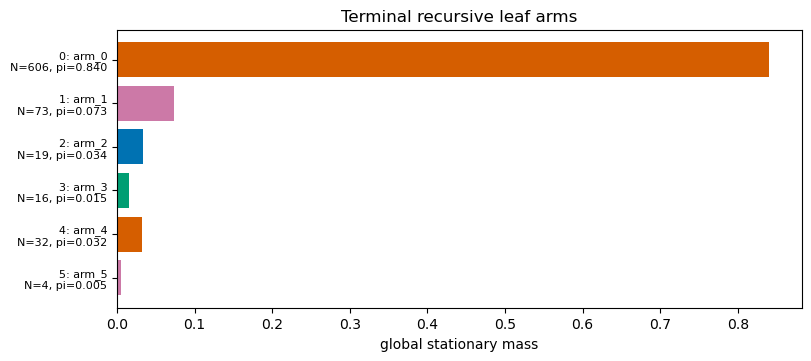

accepted split summary: /Users/meganbishop/slowmodeevo/outputs/tuning/Peromyscus_californicus/fly_style_plot_recreations/recursive_accepted_split_summary.csv


,node_id,depth,label,n_clusters,global_pi_mass,candidate_child_counts,candidate_child_conditional_pi,candidate_child_global_pi,candidate_child_balance,candidate_gap_ratio,candidate_lambda2,candidate_crispness,children


recursive split eigenvalues: /Users/meganbishop/slowmodeevo/outputs/tuning/Peromyscus_californicus/fly_style_plot_recreations/recursive_arm_tree_eigenvalues.csv


,node_id,parent_id,depth,label,path,n_clusters,global_pi_mass,split,split_reason,candidate_child_balance,...,lambda_2,lambda_3,lambda_4,lambda_5,lambda_6,lambda_7,lambda_8,lambda_9,lambda_10,lambda2_over_lambda3
0,0,None,0,arm_0,0,606,0.840353,False,parent_operator_gap_below_threshold,2.973757e-01,...,0.715582,0.715582,0.658805,0.603878,0.593474,0.574015,0.540861,0.532736,0.532736,1.000000
1,1,None,0,arm_1,1,73,0.073083,False,parent_operator_gap_below_threshold,3.885769e-11,...,0.897681,0.852302,0.805981,0.766424,0.745173,0.725013,0.725013,0.651670,0.651670,1.053242
2,4,None,0,arm_4,4,32,0.032392,False,child_global_pi_below_threshold,3.100000e-11,...,0.643099,0.500606,0.500606,0.301548,0.301548,0.294890,0.292621,0.251718,0.251495,1.284640


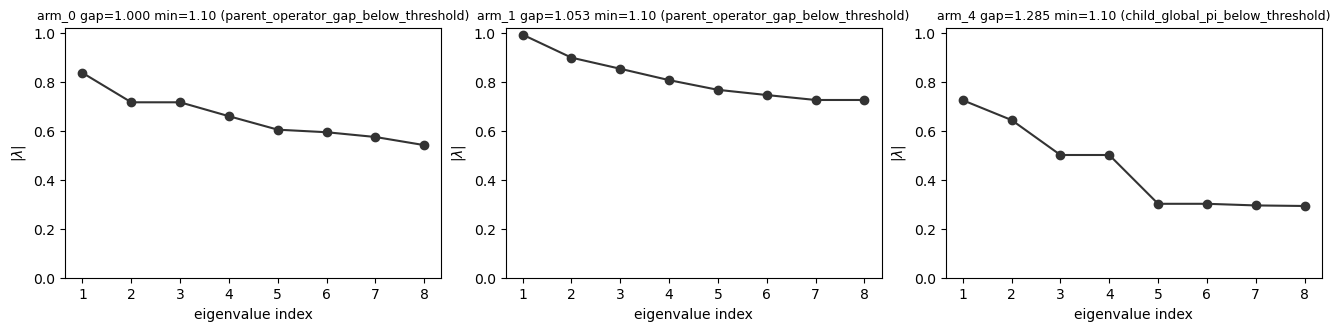

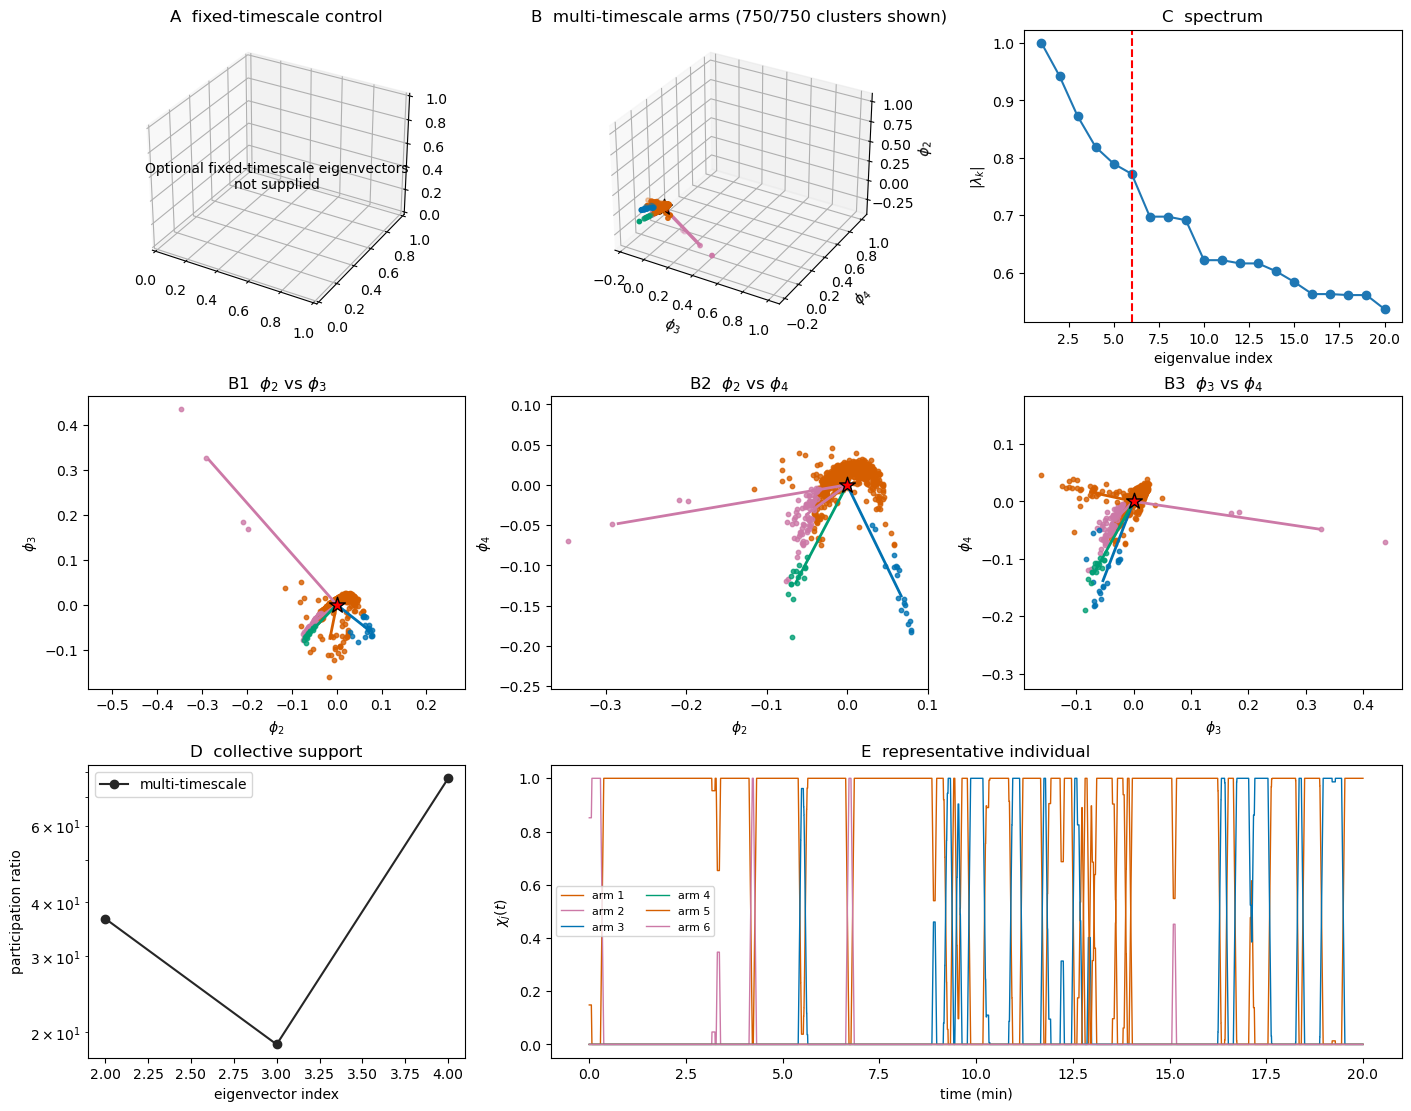

In [9]:
# Recursive GPCCA split layer. This tests each current chi arm for a nested slow mode.
RUN_RECURSIVE_ARM_SPLITTING = True
MIN_PARENT_CLUSTERS_TO_SPLIT = 20
MIN_CHILD_BALANCE = 0
MIN_PARENT_OPERATOR_GAP_RATIO = 1.1
MIN_CHILD_GLOBAL_PI = 0.05
MAX_RECURSIVE_SPLIT_DEPTH = 6  # safety cap; stopping is governed by thresholds above.
RECURSIVE_NESTED_BASINS = 2
RUN_RECURSIVE_SPLIT_DIAGNOSTICS = True




if RUN_RECURSIVE_ARM_SPLITTING:
    arm_tree = fpr.build_recursive_conditional_arm_tree(
        figure4_run,
        min_parent_clusters_to_split=MIN_PARENT_CLUSTERS_TO_SPLIT,
        min_child_balance=MIN_CHILD_BALANCE,
        min_parent_operator_gap_ratio=MIN_PARENT_OPERATOR_GAP_RATIO,
        min_child_global_pi=MIN_CHILD_GLOBAL_PI,
        max_depth=MAX_RECURSIVE_SPLIT_DEPTH,
        nested_basins=RECURSIVE_NESTED_BASINS,
    )
    leaf_run = fpr.apply_recursive_arm_tree(figure4_run, arm_tree)
    arm_tree_paths = fpr.export_recursive_arm_tree(arm_tree, FIGURE_DIR)
    print('terminal leaf arms:', leaf_run['n_basins'])
    print('arm tree nodes:', arm_tree_paths['nodes'])
    print('leaf cluster assignments:', arm_tree_paths['clusters'])

    leaf_summary = fpr.recursive_leaf_summary_table(arm_tree)
    leaf_summary_csv = FIGURE_DIR / 'recursive_leaf_arm_summary.csv'
    leaf_summary.to_csv(leaf_summary_csv, index=False)
    print('recursive leaf summary:', leaf_summary_csv)
    display(leaf_summary)
    fig_leaf_summary = fpr.plot_recursive_leaf_summary(leaf_summary)
    fpr.maybe_save(
        fig_leaf_summary, FIGURE_DIR,
        'recursive_leaf_arm_summary', SAVE_FIGURES,
    )
    plt.show()

    accepted_splits = fpr.recursive_split_summary_table(arm_tree)
    accepted_splits_csv = FIGURE_DIR / 'recursive_accepted_split_summary.csv'
    accepted_splits.to_csv(accepted_splits_csv, index=False)
    print('accepted split summary:', accepted_splits_csv)
    display(accepted_splits)

    recursive_eigenvalues = fpr.recursive_arm_tree_eigenvalue_table(arm_tree)
    recursive_eigenvalue_csv = FIGURE_DIR / 'recursive_arm_tree_eigenvalues.csv'
    recursive_eigenvalues.to_csv(recursive_eigenvalue_csv, index=False)
    print('recursive split eigenvalues:', recursive_eigenvalue_csv)
    display(recursive_eigenvalues)
    fig_recursive_evals = fpr.plot_recursive_arm_tree_eigenvalues(
        arm_tree, gap_threshold=MIN_PARENT_OPERATOR_GAP_RATIO,
    )
    fpr.maybe_save(
        fig_recursive_evals, FIGURE_DIR,
        'recursive_arm_tree_eigenvalues', SAVE_FIGURES,
    )
    plt.show()

    fig4_leaf = fpr.figure_4(leaf_run, fixed=fixed, min_cluster_time_seconds=0.0)
    fpr.maybe_save(fig4_leaf, FIGURE_DIR, 'figure_4_recursive_leaf_arms', SAVE_FIGURES)
    plt.show()
else:
    arm_tree = None
    leaf_run = figure4_run


## Main Figure 5: behavior enrichment, lag dependence, prediction, and residences

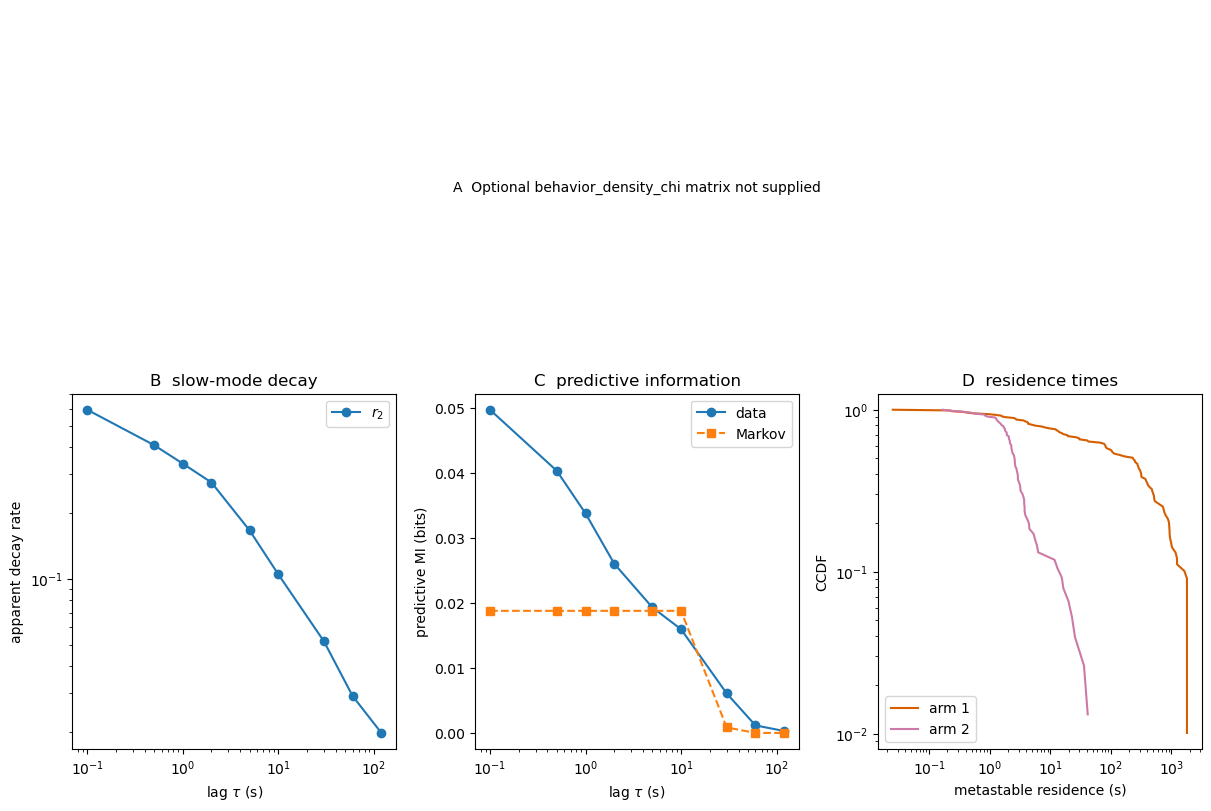

In [8]:
fig5 = fpr.figure_5(run, behavior_density=behavior_density)
fpr.maybe_save(fig5, FIGURE_DIR, 'figure_5', SAVE_FIGURES)
plt.show()


### Distribution of occupancy time over clusters

The histogram and ranked curve use pooled cumulative seconds per cluster. The red line is the active display threshold.

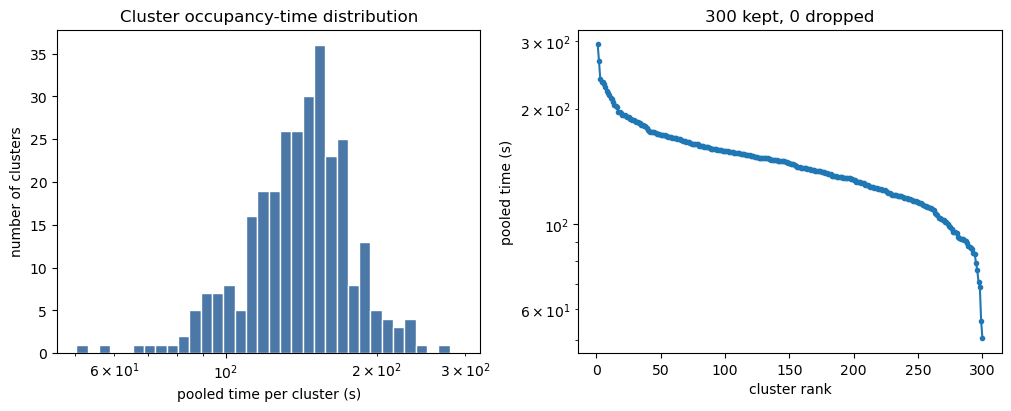

In [23]:
fig_cluster_time = fpr.plot_cluster_time_distribution(
    run, min_cluster_time_seconds=PLOT_MIN_CLUSTER_TIME_SECONDS,
)
fpr.maybe_save(fig_cluster_time, FIGURE_DIR, 'cluster_time_distribution', SAVE_FIGURES)
plt.show()


## Supplement S7: parameter and operator diagnostics

KeyboardInterrupt: 

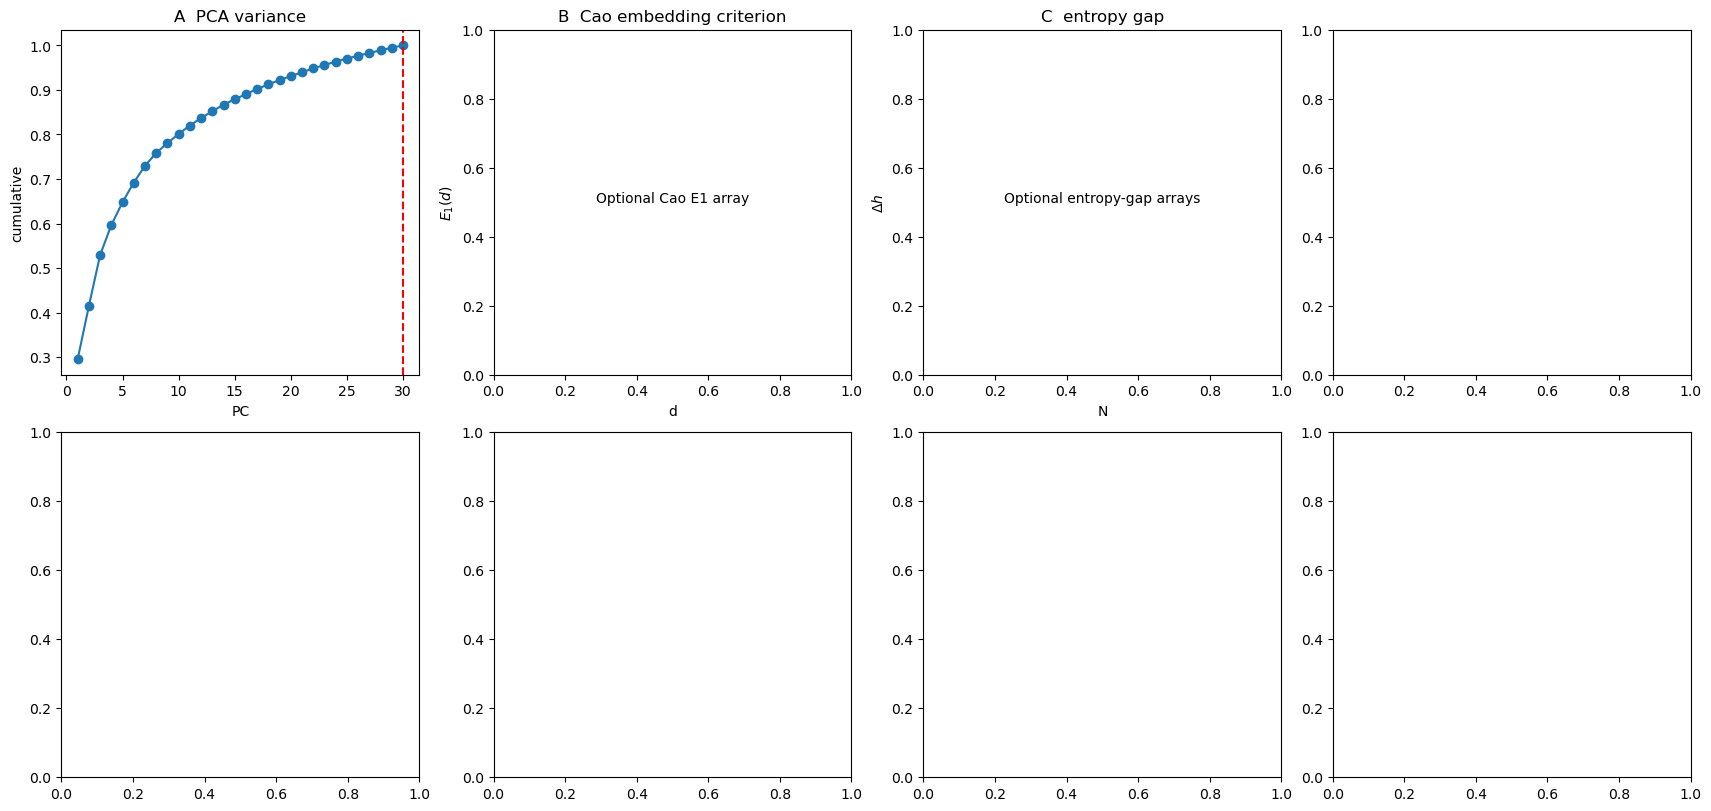

In [234]:
fig_s7 = fpr.supplement_7(run, cao_e1=cao_e1, entropy_gap=entropy_gap, cv_pi=cv_pi)
fpr.maybe_save(fig_s7, FIGURE_DIR, 'supplement_7', SAVE_FIGURES)
plt.show()


## Supplement S8: residence models and slow-membership distributions

IndexError: list index out of range

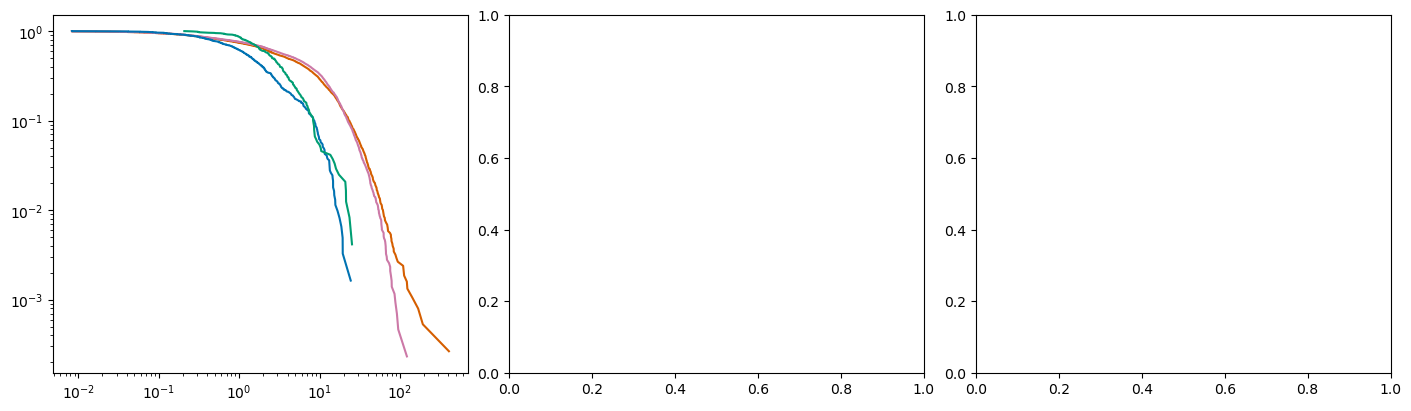

In [204]:
fig_s8 = fpr.supplement_8(run)
fpr.maybe_save(fig_s8, FIGURE_DIR, 'supplement_8', SAVE_FIGURES)
plt.show()


## Supplement S9: individual reproducibility and occupancy

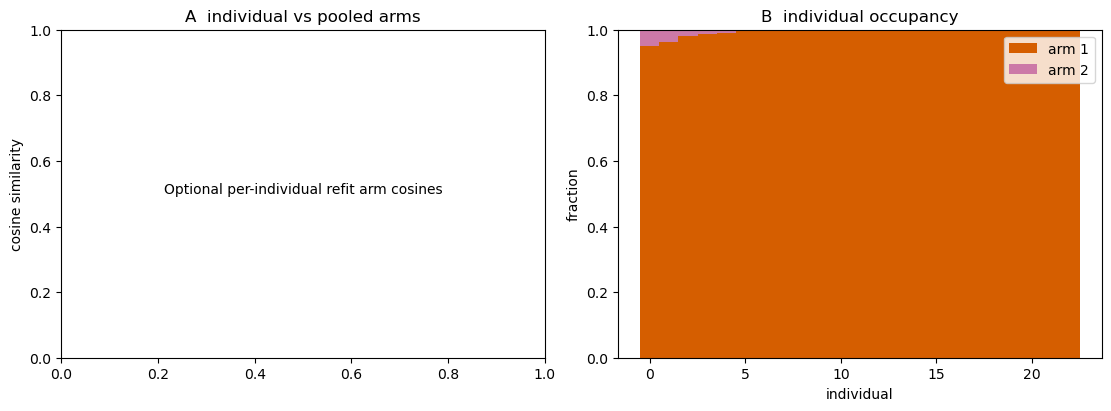

In [24]:
fig_s9 = fpr.supplement_9(run, arm_cosines=arm_cosines)
fpr.maybe_save(fig_s9, FIGURE_DIR, 'supplement_9', SAVE_FIGURES)
plt.show()


## Supplement S10: fly-only one-step Markov surrogate

This is computationally expensive because it simulates a surrogate sequence with the same length as every individual.

In [206]:
RUN_S10 = False
if RUN_S10:
    fig_s10 = fpr.supplement_10(run)
    fpr.maybe_save(fig_s10, FIGURE_DIR, 'supplement_10_fly_only', SAVE_FIGURES)
    plt.show()


## Supplement S11: fly-only smoothing-scale sensitivity

In [ ]:
RUN_S11 = False
if RUN_S11:
    fig_s11 = fpr.supplement_11(run)
    fpr.maybe_save(fig_s11, FIGURE_DIR, 'supplement_11_fly_only', SAVE_FIGURES)
    plt.show()


## MoSeq density across nested arms

This boundary-safe join maps each embedded frame to the MoSeq cluster at its recording-relative starting frame. Soft `chi` memberships are accumulated for every MoSeq cluster using the active arm model. When recursive splitting is on, this uses `leaf_run`, so split parent arms are replaced by terminal nested arms. The notebook exports the full arm-membership profile, dominant-syllable table, and within-subarm MoSeq density table.


MoSeq arm profile model: recursive_arms
MoSeq arm count: 6
non-noise MoSeq syllables included: 50


,moseq_cluster,dominant_arm,dominant_arm_label,dominance_fraction,matched_frames,arm_1_weighted_frames,arm_1_fraction,arm_2_weighted_frames,arm_2_fraction,arm_3_weighted_frames,arm_3_fraction,arm_4_weighted_frames,arm_4_fraction,arm_5_weighted_frames,arm_5_fraction,arm_6_weighted_frames,arm_6_fraction,moseq_syllable_name,moseq_category,moseq_label
0,43,0,arm 1,1.000000,34,34,1.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,very_fast,locomotion,43: very_fast
5,39,0,arm 1,0.957135,40383,38652,0.957135,876,0.021692,855,0.021172,0,0.000000,0,0.000000,0,0.000000,paused_in_rear,rear,39: paused_in_rear
6,49,0,arm 1,0.927667,1106,1026,0.927667,63,0.056962,0,0.000000,17,0.015371,0,0.000000,0,0.000000,groom_12,groom,49: groom_12
7,45,0,arm 1,0.925908,10055,9310,0.925908,425,0.042268,133,0.013227,100,0.009945,87,0.008652,0,0.000000,idle_enter_groom,groom,45: idle_enter_groom
8,3,0,arm 1,0.918247,357420,328200,0.918247,26443,0.073983,1221,0.003416,1147,0.003209,409,0.001144,0,0.000000,step_to_stop,idle,3: step_to_stop
9,0,0,arm 1,0.916370,234785,215150,0.916370,12211,0.052009,2334,0.009941,738,0.003143,4352,0.018536,0,0.000000,head_low,idle,0: head_low
10,2,0,arm 1,0.916035,293242,268620,0.916035,12884,0.043936,2144,0.007311,694,0.002367,8833,0.030122,67,0.000228,sniff_floor,idle,2: sniff_floor
11,1,0,arm 1,0.900446,147659,132959,0.900446,6808,0.046106,5945,0.040262,855,0.005790,1092,0.007395,0,0.000000,head_down,idle,1: head_down
12,13,0,arm 1,0.899610,122432,110141,0.899610,10322,0.084308,1108,0.009050,833,0.006804,28,0.000229,0,0.000000,take_a_step,idle,13: take_a_step
13,28,0,arm 1,0.896479,13321,11942,0.896479,614,0.046093,520,0.039036,245,0.018392,0,0.000000,0,0.000000,mid_rear_2,rear,28: mid_rear_2


{'requested_recordings': 16, 'matched_recordings': 16, 'missing_recordings': [], 'matched_frames': 3455776, 'excluded_boundary_frames': 9}
exported: /Users/meganbishop/slowmodeevo/outputs/tuning/Peromyscus_californicus/fly_style_plot_recreations/moseq_cluster_dominant_recursive_arms.csv
exported: /Users/meganbishop/slowmodeevo/outputs/tuning/Peromyscus_californicus/fly_style_plot_recreations/moseq_top_clusters_by_nested_arm_recursive_arms.csv


,nested_arm_label,arm_rank,moseq_cluster,dominant_arm,dominant_arm_label,dominance_fraction,matched_frames,arm_1_weighted_frames,arm_1_fraction,arm_2_weighted_frames,...,arm_3_fraction,arm_4_weighted_frames,arm_4_fraction,arm_5_weighted_frames,arm_5_fraction,arm_6_weighted_frames,arm_6_fraction,moseq_syllable_name,moseq_category,moseq_label
0,nested arm 1,1,43,0,arm 1,1.000000,34,34,1.000000,0,...,0.000000,0,0.000000,0,0.000000,0,0.000000,very_fast,locomotion,43: very_fast
1,nested arm 1,2,39,0,arm 1,0.957135,40383,38652,0.957135,876,...,0.021172,0,0.000000,0,0.000000,0,0.000000,paused_in_rear,rear,39: paused_in_rear
2,nested arm 1,3,49,0,arm 1,0.927667,1106,1026,0.927667,63,...,0.000000,17,0.015371,0,0.000000,0,0.000000,groom_12,groom,49: groom_12
3,nested arm 1,4,45,0,arm 1,0.925908,10055,9310,0.925908,425,...,0.013227,100,0.009945,87,0.008652,0,0.000000,idle_enter_groom,groom,45: idle_enter_groom
4,nested arm 1,5,3,0,arm 1,0.918247,357420,328200,0.918247,26443,...,0.003416,1147,0.003209,409,0.001144,0,0.000000,step_to_stop,idle,3: step_to_stop
5,nested arm 1,6,0,0,arm 1,0.916370,234785,215150,0.916370,12211,...,0.009941,738,0.003143,4352,0.018536,0,0.000000,head_low,idle,0: head_low
6,nested arm 1,7,2,0,arm 1,0.916035,293242,268620,0.916035,12884,...,0.007311,694,0.002367,8833,0.030122,67,0.000228,sniff_floor,idle,2: sniff_floor
7,nested arm 1,8,1,0,arm 1,0.900446,147659,132959,0.900446,6808,...,0.040262,855,0.005790,1092,0.007395,0,0.000000,head_down,idle,1: head_down
8,nested arm 1,9,13,0,arm 1,0.899610,122432,110141,0.899610,10322,...,0.009050,833,0.006804,28,0.000229,0,0.000000,take_a_step,idle,13: take_a_step
9,nested arm 1,10,28,0,arm 1,0.896479,13321,11942,0.896479,614,...,0.039036,245,0.018392,0,0.000000,0,0.000000,mid_rear_2,rear,28: mid_rear_2


exported: /Users/meganbishop/slowmodeevo/outputs/tuning/Peromyscus_californicus/fly_style_plot_recreations/moseq_density_by_nested_arm_recursive_arms.csv


,arm,arm_label,moseq_cluster,moseq_label,weighted_frames,density
0,0,arm 1,43,43: very_fast,34.0,0.000012
1,0,arm 1,39,39: paused_in_rear,38652.0,0.013353
2,0,arm 1,49,49: groom_12,1026.0,0.000354
3,0,arm 1,45,45: idle_enter_groom,9310.0,0.003216
4,0,arm 1,3,3: step_to_stop,328200.0,0.113384
...,...,...,...,...,...,...
295,5,arm 6,35,35: groom_2,4175.0,0.225603
296,5,arm 6,33,33: jump_1,0.0,0.000000
297,5,arm 6,32,32: slow_locomotion_2,0.0,0.000000
298,5,arm 6,47,47: groom_10,0.0,0.000000


exported: /Users/meganbishop/slowmodeevo/outputs/tuning/Peromyscus_californicus/fly_style_plot_recreations/individual_moseq_cluster_time_recursive_arms.csv


,individual_id,moseq_cluster,matched_frames,seconds,fraction_of_individual_time,moseq_syllable_name,moseq_category,moseq_label
0,40227.0,0,10885,90.708333,0.050397,head_low,idle,0: head_low
1,40227.0,1,7394,61.616667,0.034234,head_down,idle,1: head_down
2,40227.0,2,14773,123.108333,0.068398,sniff_floor,idle,2: sniff_floor
3,40227.0,3,34675,288.958333,0.160543,step_to_stop,idle,3: step_to_stop
4,40227.0,4,1743,14.525000,0.008070,turn_left,turn,4: turn_left
...,...,...,...,...,...,...,...,...
815,38827.0,45,994,8.283333,0.004602,idle_enter_groom,groom,45: idle_enter_groom
816,38827.0,46,249,2.075000,0.001153,groom_9,groom,46: groom_9
817,38827.0,47,0,0.000000,0.000000,groom_10,groom,47: groom_10
818,38827.0,48,74,0.616667,0.000343,groom_11,groom,48: groom_11


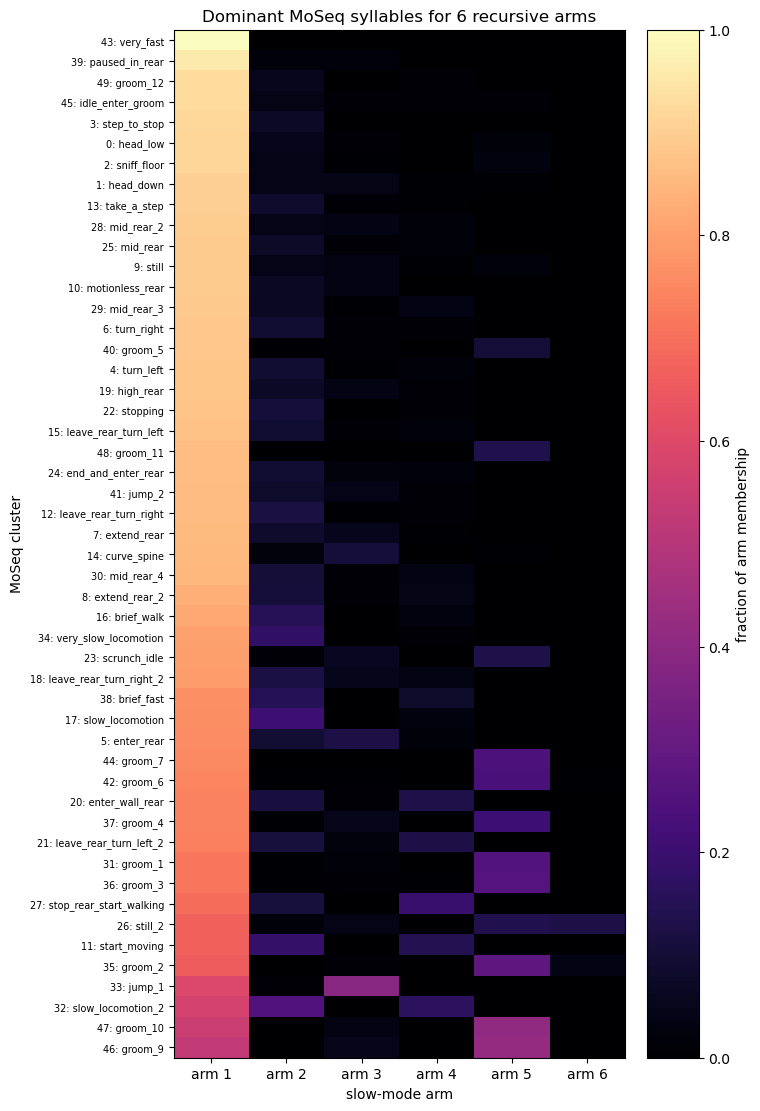

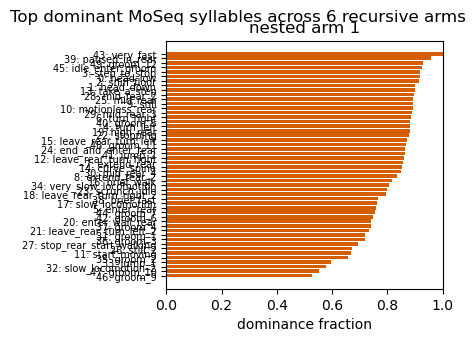

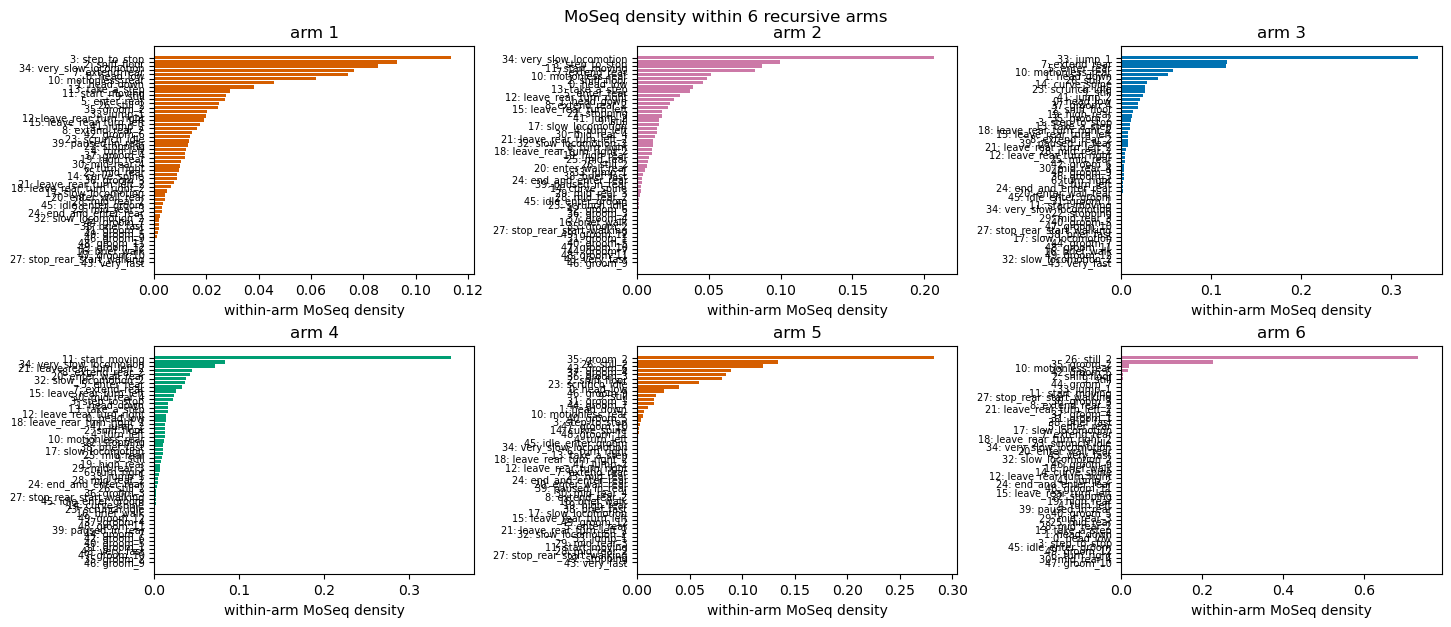

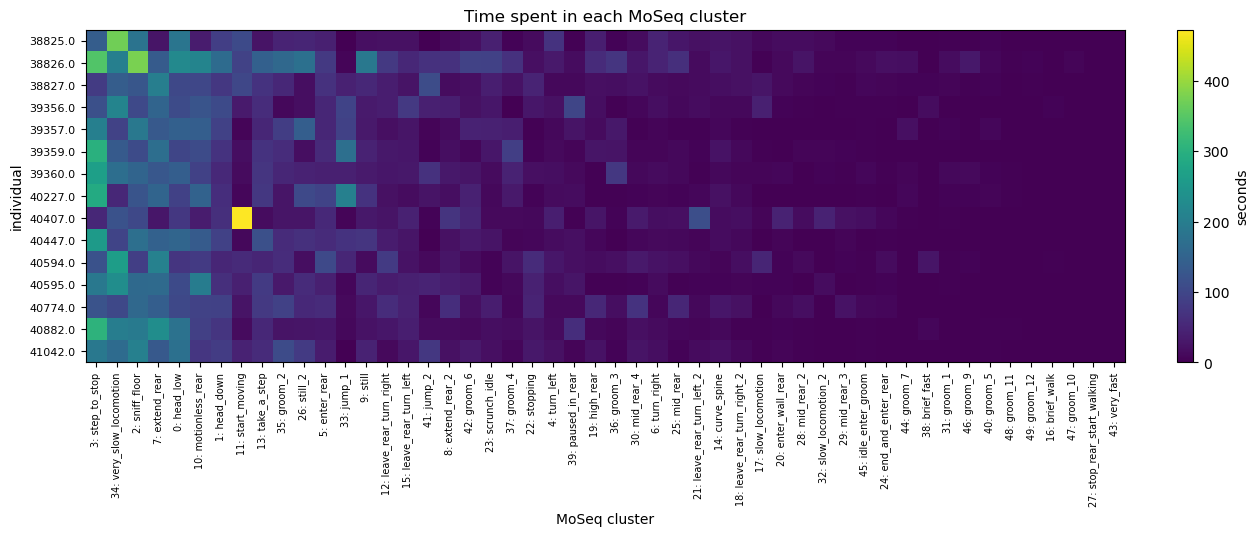

In [10]:

if RUN_MOSEQ_ARM_JOIN:
    moseq_profile_run = leaf_run if RUN_RECURSIVE_ARM_SPLITTING else figure4_run
    moseq_profile_suffix = 'recursive_arms' if RUN_RECURSIVE_ARM_SPLITTING else 'global_arms'
    print('MoSeq arm profile model:', moseq_profile_suffix)
    print('MoSeq arm count:', moseq_profile_run['n_basins'])

    moseq_arm_summary, individual_moseq_time, moseq_join_stats = fpr.moseq_arm_dominance(
        moseq_profile_run, MOSEQ_TIMESERIES_CSV,
    )
    moseq_arm_summary = fpr.add_moseq_labels(moseq_arm_summary, MOSEQ_LABELS_CSV)
    individual_moseq_time = fpr.add_moseq_labels(individual_moseq_time, MOSEQ_LABELS_CSV)
    moseq_arm_summary = fpr.exclude_moseq_categories(
        moseq_arm_summary, MOSEQ_EXCLUDED_CATEGORIES,
    )
    individual_moseq_time = fpr.exclude_moseq_categories(
        individual_moseq_time, MOSEQ_EXCLUDED_CATEGORIES,
    )
    n_non_noise = moseq_arm_summary['moseq_cluster'].nunique()
    if n_non_noise != 50:
        raise ValueError(f'Expected 50 non-noise MoSeq syllables; found {n_non_noise}')
    print('non-noise MoSeq syllables included:', n_non_noise)
    display(moseq_arm_summary)
    print(moseq_join_stats)

    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    moseq_arm_csv = FIGURE_DIR / f'moseq_cluster_dominant_{moseq_profile_suffix}.csv'
    moseq_arm_summary.to_csv(moseq_arm_csv, index=False)
    print('exported:', moseq_arm_csv)

    dominant_moseq_by_arm = fpr.dominant_moseq_clusters_by_arm(
        moseq_arm_summary,
        top_n=MOSEQ_TOP_CLUSTERS_PER_ARM,
        min_matched_frames=MOSEQ_MIN_MATCHED_FRAMES,
        min_dominance_fraction=MOSEQ_MIN_DOMINANCE_FRACTION,
    )
    dominant_moseq_by_arm_csv = FIGURE_DIR / f'moseq_top_clusters_by_nested_arm_{moseq_profile_suffix}.csv'
    dominant_moseq_by_arm.to_csv(dominant_moseq_by_arm_csv, index=False)
    print('exported:', dominant_moseq_by_arm_csv)
    display(dominant_moseq_by_arm)

    moseq_density_by_arm = fpr.moseq_density_by_arm(moseq_arm_summary)
    moseq_density_csv = FIGURE_DIR / f'moseq_density_by_nested_arm_{moseq_profile_suffix}.csv'
    moseq_density_by_arm.to_csv(moseq_density_csv, index=False)
    print('exported:', moseq_density_csv)
    display(moseq_density_by_arm)

    individual_moseq_csv = FIGURE_DIR / f'individual_moseq_cluster_time_{moseq_profile_suffix}.csv'
    individual_moseq_time.to_csv(individual_moseq_csv, index=False)
    print('exported:', individual_moseq_csv)
    display(individual_moseq_time)

    fig_moseq_arms = fpr.plot_moseq_arm_dominance(
        moseq_arm_summary,
        min_matched_frames=MOSEQ_MIN_MATCHED_FRAMES,
        max_clusters=MOSEQ_MAX_CLUSTERS_TO_PLOT,
    )
    fig_moseq_arms.axes[0].set_title(
        f'Dominant MoSeq syllables for {moseq_profile_run["n_basins"]} {moseq_profile_suffix.replace("_", " ")}'
    )
    fpr.maybe_save(
        fig_moseq_arms, FIGURE_DIR,
        f'moseq_cluster_dominant_{moseq_profile_suffix}', SAVE_FIGURES,
    )
    plt.show()

    fig_dominant_nested = fpr.plot_dominant_moseq_by_arm(dominant_moseq_by_arm)
    fig_dominant_nested.suptitle(
        f'Top dominant MoSeq syllables across {moseq_profile_run["n_basins"]} {moseq_profile_suffix.replace("_", " ")}',
        y=1.02,
    )
    fpr.maybe_save(
        fig_dominant_nested, FIGURE_DIR,
        f'moseq_top_clusters_by_nested_arm_{moseq_profile_suffix}', SAVE_FIGURES,
    )
    plt.show()

    fig_moseq_density = fpr.plot_moseq_density_by_arm(
        moseq_density_by_arm, top_n=MOSEQ_DENSITY_TOP_N,
    )
    fig_moseq_density.suptitle(
        f'MoSeq density within {moseq_profile_run["n_basins"]} {moseq_profile_suffix.replace("_", " ")}',
        y=1.02,
    )
    fpr.maybe_save(
        fig_moseq_density, FIGURE_DIR,
        f'moseq_density_by_nested_arm_{moseq_profile_suffix}', SAVE_FIGURES,
    )
    plt.show()

    fig_individual_moseq = fpr.plot_individual_moseq_cluster_time(
        individual_moseq_time, max_clusters=MOSEQ_MAX_CLUSTERS_TO_PLOT,
    )
    fpr.maybe_save(
        fig_individual_moseq, FIGURE_DIR,
        f'individual_moseq_cluster_time_{moseq_profile_suffix}', SAVE_FIGURES,
    )
    plt.show()


## Input provenance

- Direct pipeline outputs: PCA spectrum, projections, states, transfer operator, eigenvectors, stationary distribution, `chi`, hard basin assignments, and residences.
- Optional fixed-timescale input: required for the negative-control panels in Figure 4 and S7.
- Optional behavior-density input: required for Figure 5A because the behavioral-map coordinates are not part of the all-pair-distance pipeline.
- Optional diagnostic matrices: Cao E1, entropy gap, held-out predictive information, and per-individual arm-refit cosines can be imported without rerunning the producing notebook.